c:\Users\erith\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\erith\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ PSPNet Hair Segmentation loaded on cpu


c:\Users\erith\OneDrive\Документы\GitHub\Hairstylist\hair_seg_model\networks\pspnet.py:60: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  upsampled = F.upsample(pooled, size=(h, w), mode='bilinear')
c:\Users\erith\OneDrive\Документы\GitHub\Hairstylist\hair_seg_model\networks\pspnet.py:80: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  f = F.upsample(x, size=size, mode='bilinear')


✅ Hair mask saved to results/hair_only.png


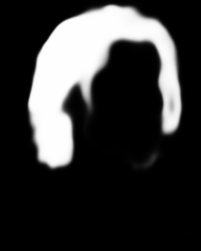

In [2]:

from src.segmentation import HairSegmenter

segmenter = HairSegmenter()
segmenter.predict('data/input.jpeg', 'results/hair_only.png')

In [3]:
from src.refinement import refine_hair_mask

# Запуск улучшения маски
refine_hair_mask('results/hair_only.png', 'results/hair_only_refined.png')

✅ Refined hair mask saved to results/hair_only_refined.png


c:\Users\erith\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\erith\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ PSPNet Hair Segmentation loaded on cpu


c:\Users\erith\OneDrive\Документы\GitHub\Hairstylist\hair_seg_model\networks\pspnet.py:60: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  upsampled = F.upsample(pooled, size=(h, w), mode='bilinear')
c:\Users\erith\OneDrive\Документы\GitHub\Hairstylist\hair_seg_model\networks\pspnet.py:80: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  f = F.upsample(x, size=size, mode='bilinear')


✅ Hair mask saved to results/hair_mask.png
✅ Hair with alpha saved to results/hair_only.png


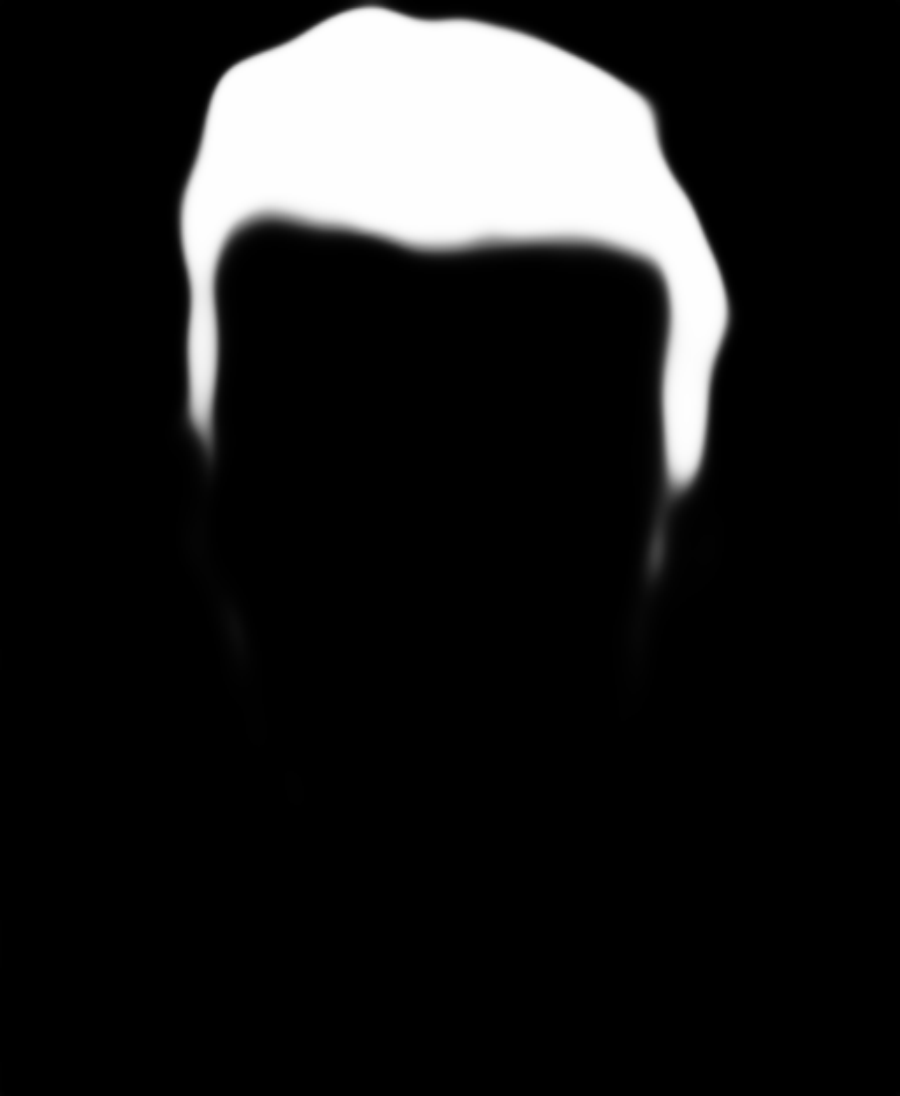

In [6]:
# Этап 1: Сегментация (создаёт 2 файла)
from src.segmentation import HairSegmenter

segmenter = HairSegmenter()
segmenter.predict(
    image_path='data/input.jpeg',
    output_path='results/hair_only.png',      # Цветное с альфа-каналом
    mask_path='results/hair_mask.png'         # Чистая маска (чёрно-белая)
)

In [1]:
# Ячейка 1: Импорт
from src.face_shape_analyzer import FaceShapeAnalyzer

# Ячейка 2: Анализ
analyzer = FaceShapeAnalyzer()
shape, confidence, probs = analyzer.analyze('data/input.jpeg')

# Ячейка 3: Вывод результатов
if shape:
    print(f"✅ Форма лица: {shape} ({confidence:.1%})")
    print("\nРекомендации:")
    for rec in analyzer.get_recommendations(shape):
        print(f"  {rec}")
else:
    print(f"❌ Ошибка: {confidence}")

c:\Users\erith\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Загрузка модели face_shape_classification...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 920.94it/s, Materializing param=vit.layernorm.weight]                                 


✅ Модель загружена на cpu
✅ Форма лица: Продолговатый (98.5%)

Рекомендации:
  ✅ Короткие стрижки (до подбородка)
  ✅ Челка (скрывает длину)
  ✅ Волнистые волосы
  ⚠️ Избегайте длинных прямых волос


⏳ Загрузка Stable Diffusion Inpainting...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\erith\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\erith\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 346.43it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: C:\Users\erith\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_id

✅ Stable Diffusion загружен на cpu

🎨 Перенос прически...
   Целевое изображение: data/input.jpeg
   Донорское изображение: data/reference_hairstyle.jpg
⏳ Подготовка масок...
⏳ Запуск генерации с переносом стиля...


100%|██████████| 40/40 [03:00<00:00,  4.52s/it]


✅ Генерация завершена!
✅ Результат сохранён: results/hairstyle_transferred.png
📸 Оригинальное фото:


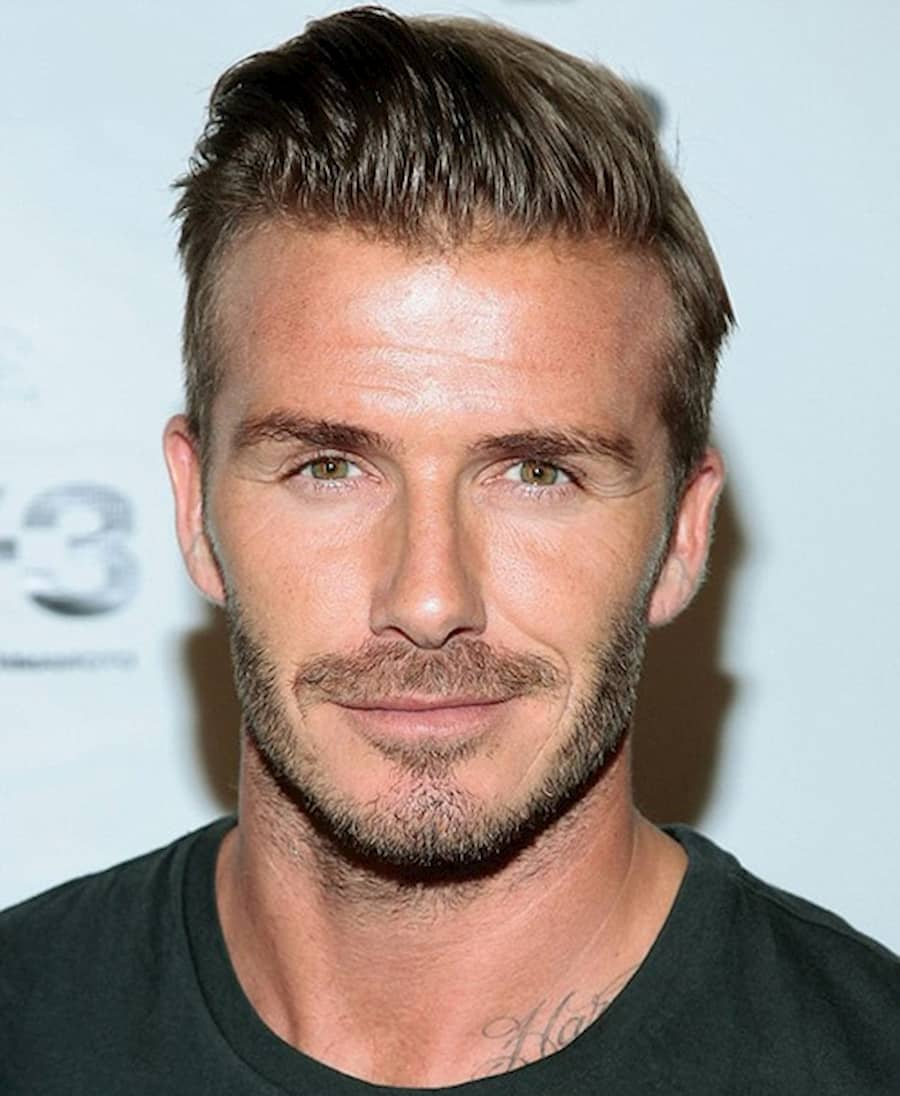


📸 Донорская прическа:


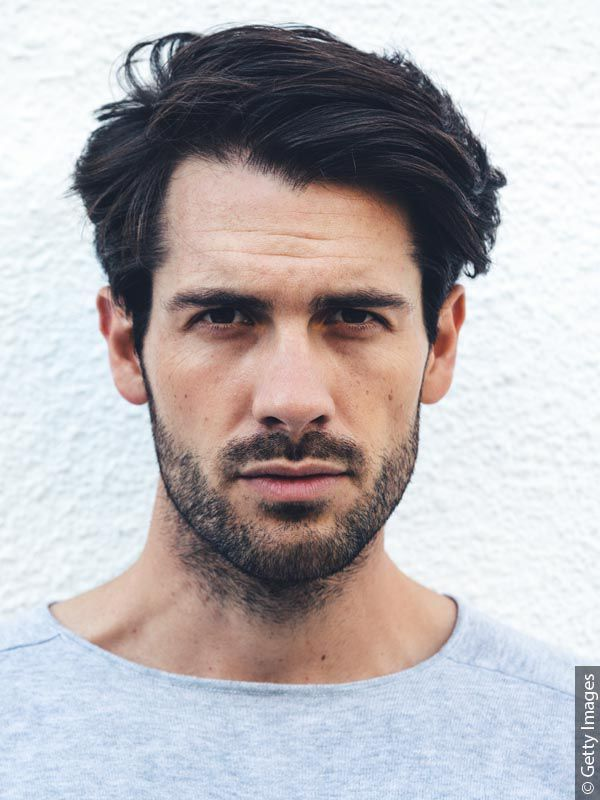


📸 Результат переноса:


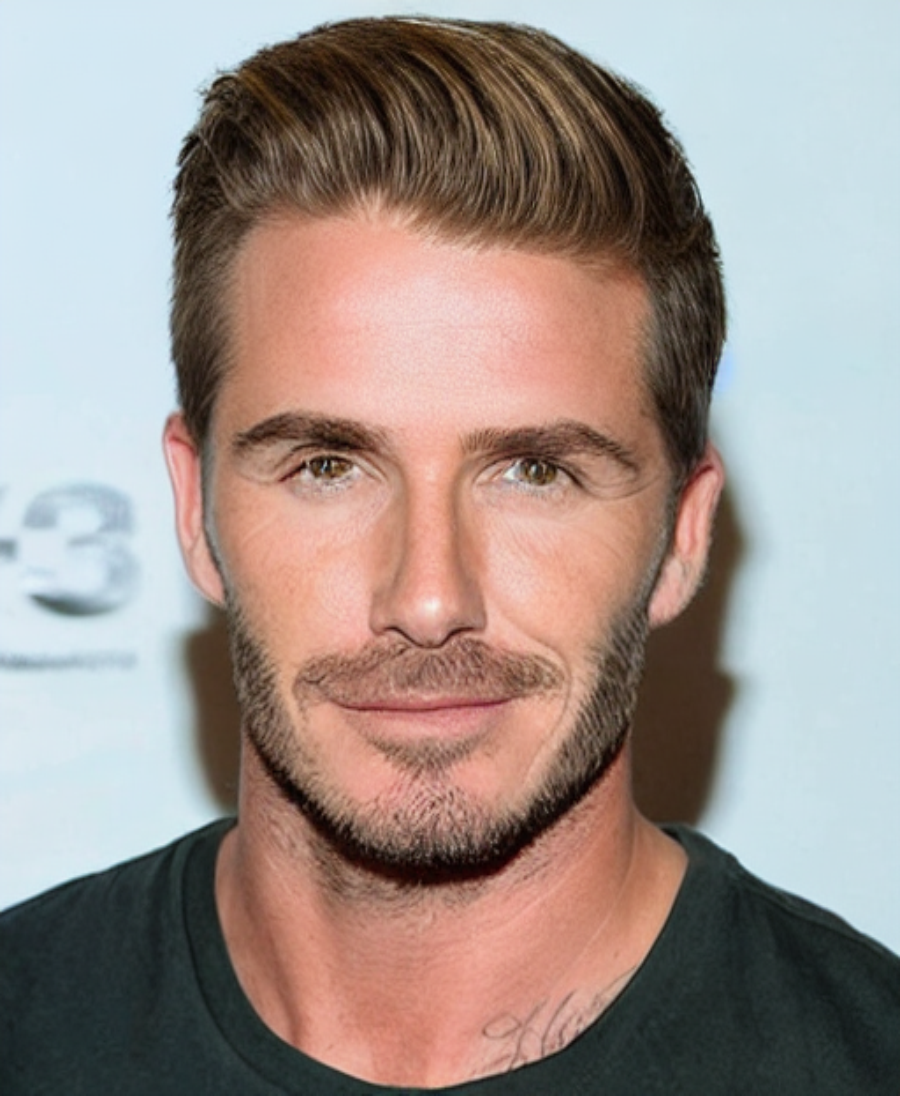

In [3]:
# Ячейка 1: Импорт
from src.hairstyle_transfer import HairstyleTransfer
from IPython.display import Image, display

# Ячейка 2: Создание трансферера
transfer = HairstyleTransfer()

# Ячейка 3: Перенос прически
result = transfer.transfer_hairstyle(
    target_image_path='data/input.jpeg',  # Ваше фото
    reference_image_path='data/reference_hairstyle.jpg',  # Фото с прической которую хотите
    prompt="professional portrait, realistic hair, high quality",
    negative_prompt="ugly, blurry, distorted, bad anatomy",
    num_inference_steps=50,
    guidance_scale=7.5,
    strength=0.8,
    output_path='results/hairstyle_transferred.png'
)

# Ячейка 4: Показать результаты
print("📸 Оригинальное фото:")
display(Image(filename='data/input.jpeg'))

print("\n📸 Донорская прическа:")
display(Image(filename='data/reference_hairstyle.jpg'))

print("\n📸 Результат переноса:")
display(Image(filename='results/hairstyle_transferred.png'))

In [1]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
